# Plotting GPR data
The data has already been preprocessed by Dr. Christophe Ogier & Dr. Ilaria Santin. Several steps have been conducted:

1. Filtering
2. Bed picking
3. ...

In [1]:
# Cell 1: Imports and inputs
import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import gpr_processing as gpr
import rasterio
import cmcrameri.cm as cmc
from rasterio.plot import show as rioshow

pixel_size = 20.0    # meters
interp_method = 'linear'  # 'linear' | 'cubic' | 'nearest'

### Set up paths

In [2]:
root_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/gpr/20250515_Alphubel"
project_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes"

# List your TXT files
txt_files = [
    root_dir + "/bed picks_south/20060101_GPR_picks_south.txt" # Alphubel south
]

# Optional local orthophoto (GeoTIFF). Leave None to use online basemap instead.
ortho_path = None  # e.g., os.path.join(root_dir, "orthophoto.tif")

In [3]:
points = gpr.load_points_from_txt(txt_files, epsg=2056, drop_duplicates=True, aggregate_duplicates='mean')
coverage = gpr.make_coverage_polygon(points, method='convex', buffer_m=0.0)  # avoids optimizealpha
print(points.shape, coverage.crs, coverage.geometry.iloc[0].geom_type)

(7424, 4) EPSG:2056 Polygon


### Download Orhophotos from Swisstopo

In [4]:
# set download dir
ortho_dir = project_dir + "/products/figures/gpr_figures/ice_thickness_maps/"

# Download orthophoto (swisstopo WMS) for coverage area, but with extra margin
ortho_buffer_m = 200  # increase to cover more area than the heatmap
bbox = gpr.bbox_from_gdf(coverage, buffer_m=ortho_buffer_m)  # add margin around coverage

out_ortho = os.path.join(ortho_dir, "alphubel_orthophoto.tif")
_, ortho_transform, ortho_crs = gpr.download_swisstopo_orthophoto(
    bbox, out_ortho, crs_epsg=2056, pixel_size=0.5,  # 1 m/px; use 0.5 for finer (bigger download)
    layer="ch.swisstopo.swissimage", fmt="image/jpeg"
)
print("Orthophoto saved:", out_ortho)

Orthophoto saved: /Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/products/figures/gpr_figures/ice_thickness_maps/alphubel_orthophoto.tif


### Interpolate GPR ice thickness to grid

In [5]:
# Interpolation settings
pixel_size = 3.0    # meters (was 20.0)
interp_method = 'linear'  # or 'cubic'|'nearest'

# Interpolate GPR thickness to a grid (returns grid and its geotransform)
grid, grid_transform, grid_crs = gpr.interpolate_to_grid(
    points, value_col='thickness',
    pixel_size=pixel_size, method=interp_method,
    polygon_mask=coverage, padding=0.0
)
print("Grid shape:", grid.shape)

Grid shape: (69, 50)


### Load other data for map

In [6]:
# GPR line tracks (force LV95 / EPSG:2056)
gpr_lines_path = root_dir + "/bed picks_south/20060101_GPR_picks.shp"
gpr_lines = gpd.read_file(gpr_lines_path)

# Always assign EPSG:2056 (LV95), even if CRS is missing or wrong in the file
gpr_lines = gpr_lines.set_crs(epsg=2056, allow_override=True)

print("GPR lines:", len(gpr_lines), "features; CRS:", gpr_lines.crs)

# Load latest borehole positions
bh_csv = root_dir + "/../../icetemperature_data/thermistor_settings/thermistor_coordinates.csv"
keep_bh = ["AH1G", "AH2G", "AH3G", "AH4TT", "AH5TT", "AH6TT"]
boreholes, bh_missing = gpr.load_borehole_positions(bh_csv, keep_names=keep_bh)

GPR lines: 1 features; CRS: EPSG:2056


In [7]:
boreholes

,name,date,x,x,y,y,geometry
16,AH1G,06.08.25,2633226.81,2633226.81,1100604.12,1100604.12,POINT (2633226.81 1100604.12)
17,AH2G,06.08.25,"2633183,50",2633183.50,"1100551,82",1100551.82,POINT (2633183.5 1100551.82)
18,AH3G,06.08.25,"2633245,17",2633245.17,"1100634,30",1100634.30,POINT (2633245.17 1100634.3)
19,AH4TT,06.08.25,"2633203,23",2633203.23,"1100579,67",1100579.67,POINT (2633203.23 1100579.67)
20,AH5TT,21.08.24,"2633249,72",2633249.72,"1100537,76",1100537.76,POINT (2633249.72 1100537.76)
22,AH6TT,05.08.25,"2633251,63",2633251.63,"1100564,25",1100564.25,POINT (2633251.63 1100564.25)


### Plot Alphubel ice thickness heatmap

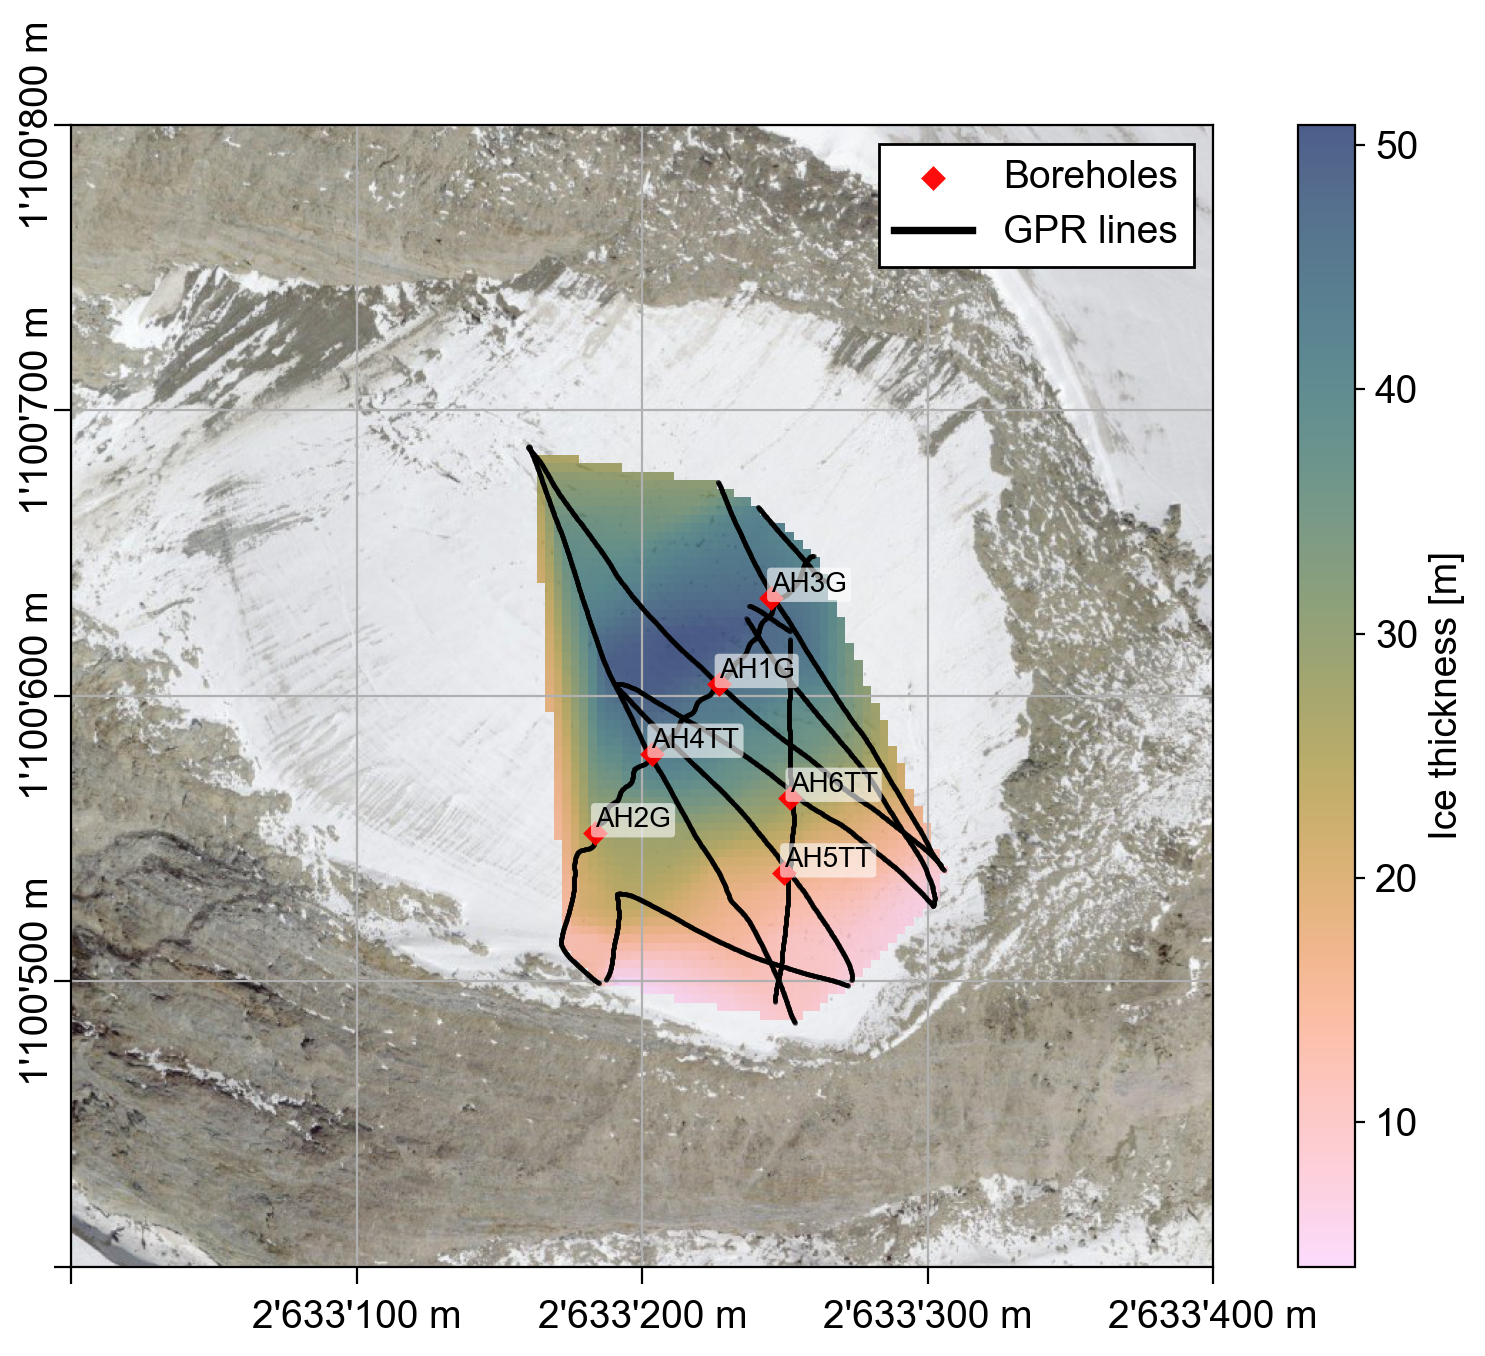

In [12]:
with rasterio.open(out_ortho) as src:
    fig, ax = plt.subplots(figsize=(9,7), dpi=200)
    rioshow(src, ax=ax)

    extent = (
        grid_transform.c,
        grid_transform.c + grid_transform.a * grid.shape[1],
        grid_transform.f + grid_transform.e * grid.shape[0],
        grid_transform.f,
    )

    cm = cmc.batlow_r  # Use the reversed colormap directly
    im = ax.imshow(grid, extent=extent, origin='upper', cmap=cm, alpha=0.7)
    # coverage.boundary.plot(ax=ax, color='k', linewidth=1.0, label='Coverage', linestyle='dotted')

    # Draw MultiPoint as tiny points (keep geometry as-is)
    xs, ys = [], []
    for geom in gpr_lines.geometry:
        if geom.geom_type == 'MultiPoint':
            xs.extend([p.x for p in geom.geoms])
            ys.extend([p.y for p in geom.geoms])
        elif geom.geom_type == 'Point':
            xs.append(geom.x); ys.append(geom.y)
    pt_size = 3   # points^2; try 1–5
    ax.scatter(xs, ys, s=pt_size, c='k', marker='o',
               linewidths=0, alpha=0.5, zorder=6, label='_nolegend_', rasterized=True)

    # Plot boreholes as simple, larger dots (no outline)
    if not boreholes.empty:
        ax.scatter(boreholes.geometry.x, boreholes.geometry.y,
                   s=40, marker='D', color='red',
                   linewidths=0, alpha=0.95, zorder=7, label='Boreholes')
        # Optional labels
        for _, r in boreholes.iterrows():
            ax.text(r.geometry.x, r.geometry.y, r['name'],
                    fontsize=10, color='k', ha='left', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.6),
                    zorder=8)

    # Proxy line for legend only (draws nothing, just adds a handle)
    ax.plot([], [], color='k', linewidth=0.4, label='GPR lines')

    cb = fig.colorbar(im, ax=ax, label='Ice thickness [m]')

    # Zoom to bbox (EPSG:2056)
    x0, x1 = 2633000, 2633400
    y0, y1 = 1100400, 1100800
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)

    # Clean LV95-like axes
    gpr.format_axes_coords(ax, x_step=100, y_step=100, thousands='apostrophe', unit='m', decimals=0)
    gpr.format_plot(ax=ax, legend_loc='upper right', cbar=cb, y_tick_rotation=90, x_tick_rotation=0)